In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
output_dir = Path("glauber_output")
file_paths = sorted(output_dir.glob("*.npz"))

if len(file_paths) != 16:
    raise ValueError(f"Expected 16 NPZ files in {output_dir}, found {len(file_paths)}.")

expected_fields = {"Npart", "Ncoll", "b"}
chunks = {field: [] for field in sorted(expected_fields)}

for file_path in file_paths:
    with np.load(file_path, allow_pickle=False) as archive:
        if set(archive.files) != expected_fields:
            raise ValueError(
                f"Unexpected fields in {file_path.name}: {archive.files}; "
                f"expected {sorted(expected_fields)}."
            )

        lengths = {len(archive[field]) for field in expected_fields}
        if len(lengths) != 1:
            raise ValueError(f"Arrays have inconsistent lengths in {file_path.name}.")

        for field in chunks:
            chunks[field].append(archive[field].copy())

data = {field: np.concatenate(arrays) for field, arrays in chunks.items()}
Npart = data["Npart"]
Ncoll = data["Ncoll"]
b = data["b"]

print(f"Loaded {len(file_paths)} files with {len(Npart):,} total events")
print("Files:", ", ".join(path.name for path in file_paths))

Loaded 16 files with 21,674 total events
Files: worker_00.npz, worker_01.npz, worker_02.npz, worker_03.npz, worker_04.npz, worker_05.npz, worker_06.npz, worker_07.npz, worker_08.npz, worker_09.npz, worker_10.npz, worker_11.npz, worker_12.npz, worker_13.npz, worker_14.npz, worker_15.npz


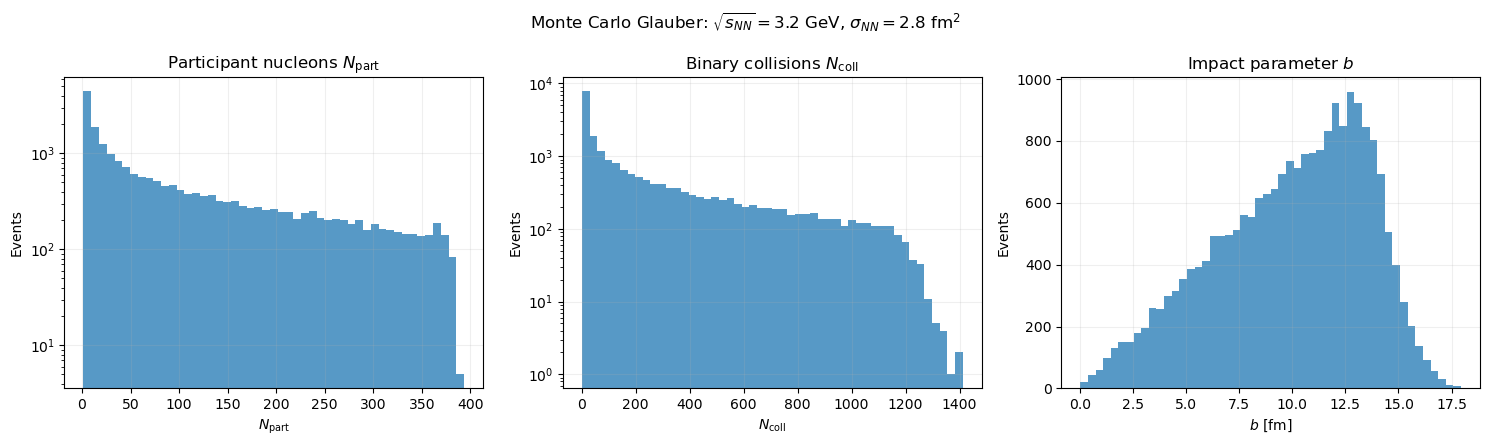

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Npart is integer-valued. Align fixed-width bins on half-integers so every
# bin contains the same number of possible counts and no sawtooth is induced.
npart_bin_width = 8
npart_bins = np.arange(
    Npart.min() - 0.5,
    Npart.max() + npart_bin_width + 0.5,
    npart_bin_width,
)

histograms = [
    (Npart, r"$N_{\mathrm{part}}$", r"Participant nucleons $N_{\mathrm{part}}$", True, npart_bins),
    (Ncoll, r"$N_{\mathrm{coll}}$", r"Binary collisions $N_{\mathrm{coll}}$", True, 50),
    (b, r"$b$ [fm]", r"Impact parameter $b$", False, 50),
]

for ax, (values, xlabel, title, log_scale, bins) in zip(axes, histograms):
    ax.hist(values, bins=bins, log=log_scale, histtype="stepfilled", alpha=0.75)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events")
    ax.set_title(title)
    ax.grid(alpha=0.2)

fig.suptitle(
    r"Monte Carlo Glauber: $\sqrt{s_{NN}}=200$ GeV, "
    r"$\sigma_{NN}=4.2\ \mathrm{fm}^2$"
)
fig.tight_layout()
plt.show()